# **Data Augmentation**
- **RandomCrop**: PyTorch 라이브러리 사용
  - 원본 (1장) + RandomCrop (127장) = 총 128장
- **Stable Diffsuion**: 3장 구현 완료
  - 원본 (1장) + Stable Diffusion V2 (63장) = 총 64장
- **RandomCrop + Stable Diffusion V2**: 구현 예정 (최종 목표)
  - 원본 (1장) + Stable Diffusion V2 (63장) + RandomCrop (64장) = 총 128장

## RandomCrop

### Dataset load
  - **Dataset**: ImageNet-R (https://github.com/hendrycks/imagenet-r)
  - art, cartoons, deviantart, graffiti, embroidery, graphics, origami, paintings, patterns, plastic objects, plush objects, sculptures, sketches, tattoos, toys, and video game
  - 200 ImageNet classes resulting in 30,000 images.

In [ ]:
%cd /content
!wget -O imagenet-r.tar https://people.eecs.berkeley.edu/~hendrycks/imagenet-r.tar
!tar -xf imagenet-r.tar

/content
--2026-05-30 04:09:45--  https://people.eecs.berkeley.edu/~hendrycks/imagenet-r.tar
Resolving people.eecs.berkeley.edu (people.eecs.berkeley.edu)... 128.32.244.190
Connecting to people.eecs.berkeley.edu (people.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2191079936 (2.0G) [application/x-tar]
Saving to: ‘imagenet-r.tar’

imagenet-r.tar      100%[===================>]   2.04G  64.2MB/s    in 38s     

2026-05-30 04:10:23 (54.7 MB/s) - ‘imagenet-r.tar’ saved [2191079936/2191079936]



- torchvision.datasets.ImageFolder로 로드
- (image, label) 튜플 형태로 반환
  - image: PIL Image
  - label: 클래스 인덱스 (0~199)

In [ ]:
import torchvision.datasets as dset

dataset = dset.ImageFolder(root="/content/imagenet-r")
print(f"클래스 수: {len(dataset.classes)}")
print(f"전체 이미지 수: {len(dataset)}")

클래스 수: 200
전체 이미지 수: 30000


### Data Preprocessing
- CLIP Input size: 224x224
- PIL Image는 `(H, W, C)` numpy 형태이므로, Pytorch에서는 `(C, H, W)` Tensor 형태로 변환해줘야 함
- CLIP는 학습할 때 Image를 특정 mean, std로 normalize. → 해당 부분은 생략함
  - mean = (0.48145466, 0.4578275,  0.40821073)
  - std  = (0.26862954, 0.26130258, 0.27577711)
- 원본 이미지에 `base_transform` 적용 시 shape: (3, 224, 224) → `unsqueeze(0)`으로 배치 차원 추가 → (1, 3, 224, 224)
- `crop_transform`을 63번 반복 적용 → (3, 224, 224) Tensor 63개 → `torch.stack`으로 합산 → (n장, 3, 224, 224)
  - `torch.stack`: 여러 개의 Tensor를 새로운 차원으로 쌓아 하나로 합침
- `torch.cat([original, crops], dim=0)`으로 원본 1장 + crop 63장을 배치 방향으로 합침 → 최종 (n+1장, 3, 224, 224)
  - `torch.cat`: 단순히 기존 차원에 이어 붙임

In [ ]:
import torch
from torchvision import transforms
from PIL import Image

def make_views(image, n_views):
    """
    원본 1장 + RandomCrop n_views장
    """
    # 원본 전처리 (crop 없이 resize만)
    base_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    # RandomCrop 전처리
    crop_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.ToTensor(),
    ])

    original = base_transform(image).unsqueeze(0) # (1, 3, 224, 224)
    crops = torch.stack([crop_transform(image)
                         for _ in range(n_views)]) # (n장, 3, 224, 224)
    all_views = torch.cat([original, crops], dim=0) # (n+1장, 3, 224, 224)

    return all_views

### Visualization
- plot 생성
- Tensor → Image 변환: `imshow()`는 `(H, W, C)` 형태를 요구함
  - (3, 224, 224) → (224, 224, 3)
- ax.axis("off")로 각 이미지의 축, 눈금 제거
- 첫 번째 이미지(원본)는 "original"로 표시, 나머지는 "crop {i}"로 표시

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_views(all_views, n_cols):
    """
    최종 Image grid로 시각화
    """
    n = len(all_views)
    n_rows = -(-n // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))

    for i, ax in enumerate(axes.flatten()):
        if i < n:
            img = all_views[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title("original" if i == 0 else f"crop {i}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Test
- dataset에서 image, label 로드
- `make_views`로 원본 1장 + RandomCrop 127장 = 총 128장 생성
- `visualize_views`로 8×8 grid 시각화

Total views: 128


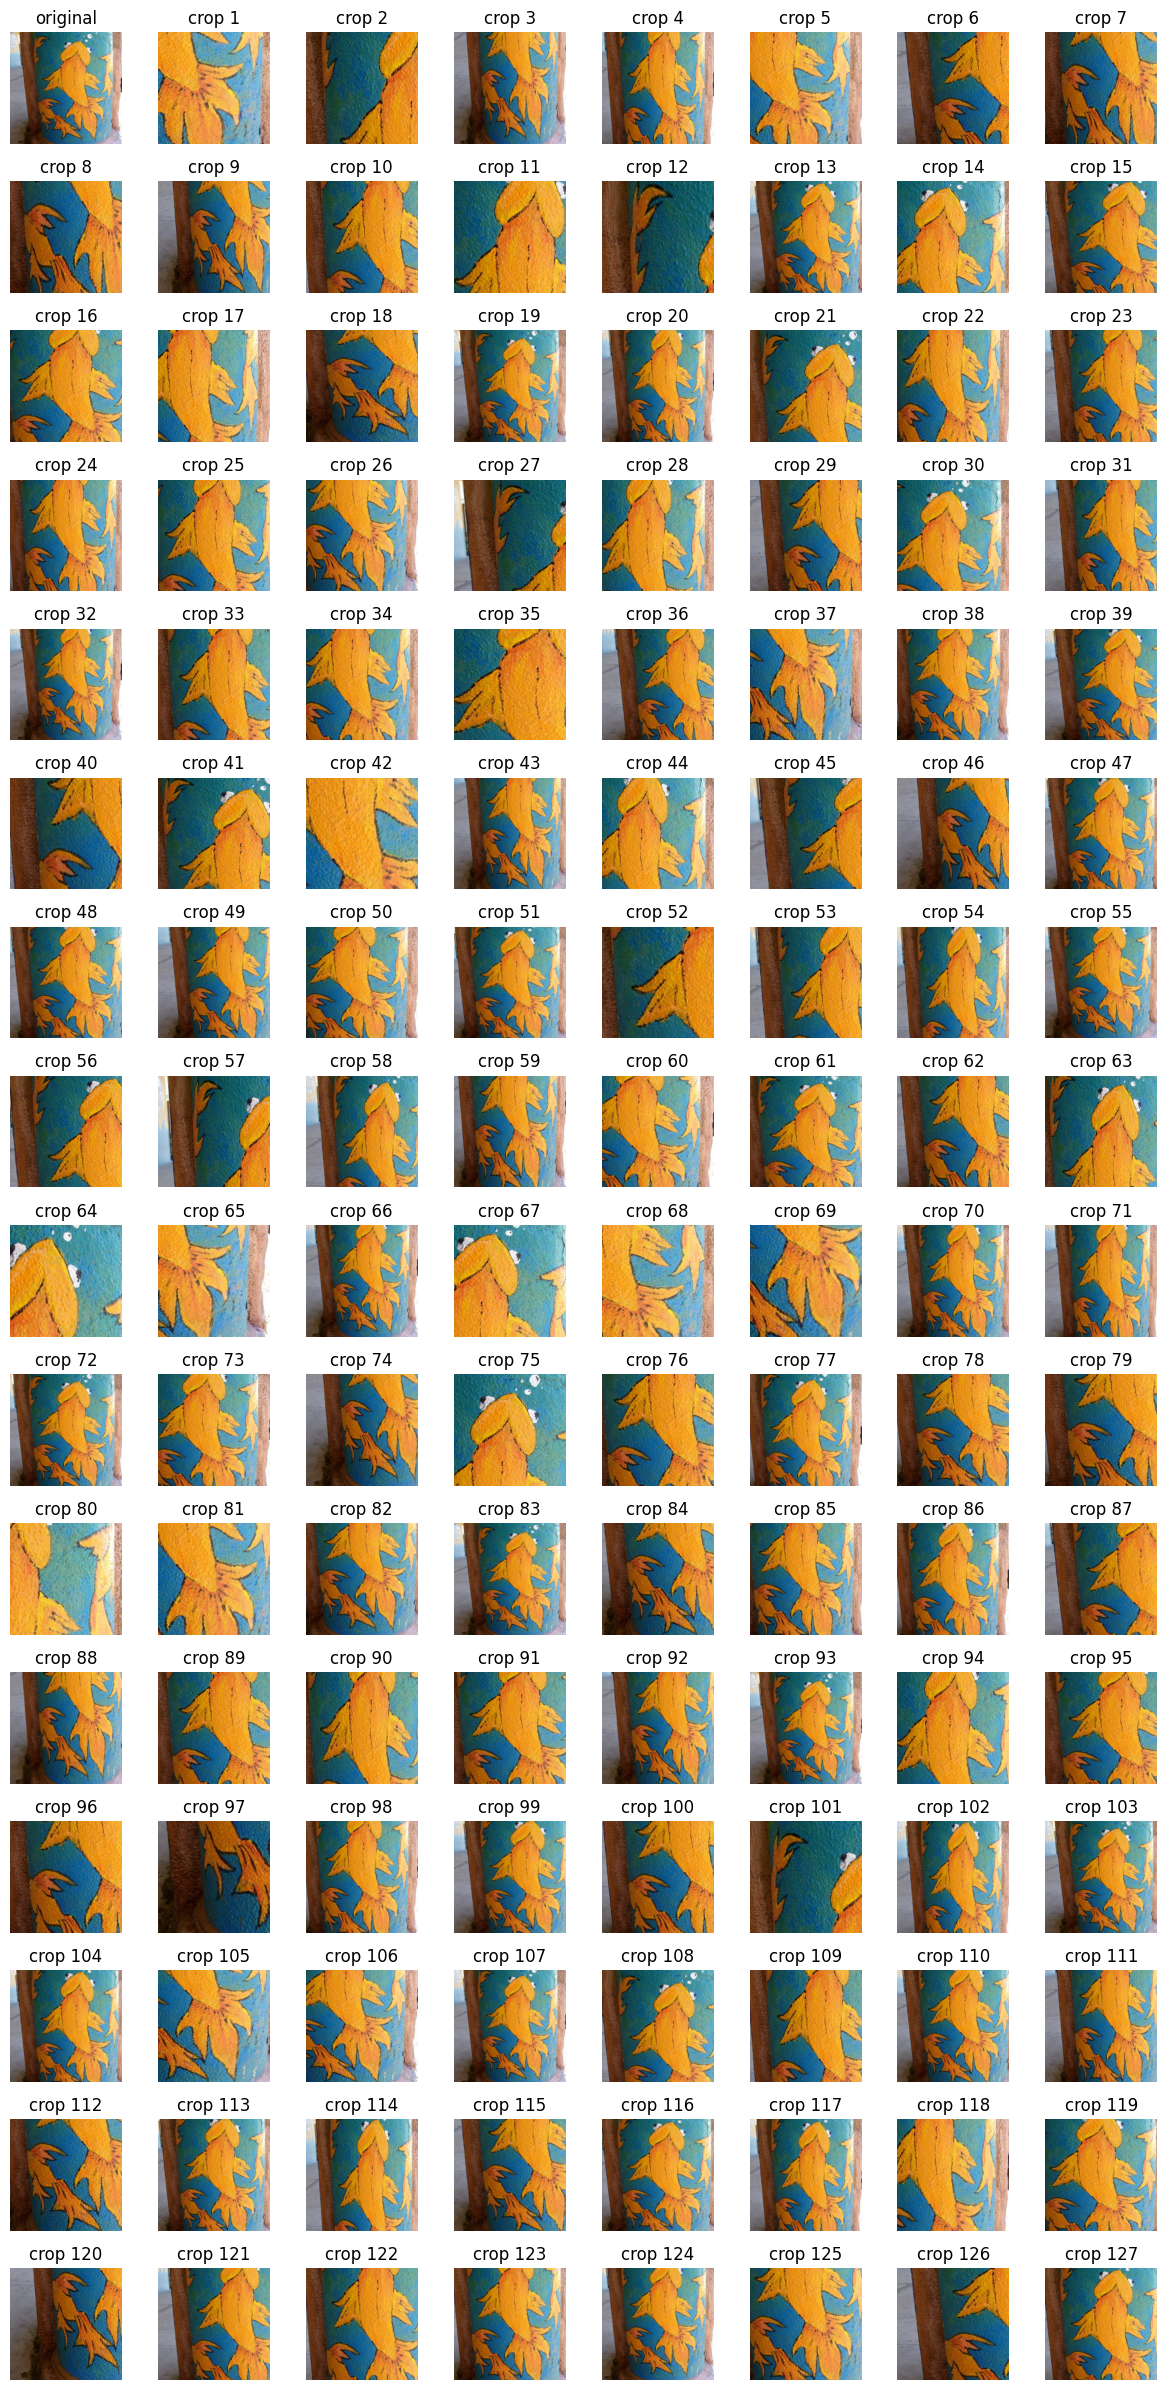

In [ ]:
image, label = dataset[0]

all_views = make_views(image, n_views=127)
print(f"Total views: {all_views.shape[0]}")

visualize_views(all_views, n_cols=8)

## Stable Diffusion
- DiffTPT: https://github.com/chunmeifeng/DiffTPT
- 주요 Task 참고: https://github.com/huggingface/diffusers#popular-tasks--pipelines
  - DDPM: 텍스트 없이 랜덤 이미지 생성. 우리 목적과 무관.
  - Stable Diffusion Text-to-Image: 텍스트로 이미지 생성. 우리 목적과 무관.
  - unCLIP: 텍스트로 이미지 생성. CLIP 기반. 우리 목적과 무관.
  - DeepFloyd IF: 텍스트로 고품질 이미지 생성. 우리 목적과 무관.
  - Kandinsky: 텍스트로 이미지 생성. 우리 목적과 무관.
  - **ControlNet**: 이미지 구조(엣지, 포즈)를 유지하면서 텍스트로 스타일 변형. 원본 구조 유지에 강력.
  - **InstructPix2Pix**: 텍스트 명령으로 이미지 편집. 예) "make it a sketch".
  - **Stable Diffusion Image-to-Image**: 이미지+텍스트로 변형. strength로 변형 정도 조절 가능.
  - Stable Diffusion Inpainting: 이미지 일부분만 편집. 우리 목적과 무관.
  - **Stable Diffusion Image Variation**: 이미지만으로 유사 이미지 생성. 스타일 변형이 큼.
  - Stable Diffusion Upscale: 이미지 해상도 향상. 우리 목적과 무관.
  - Stable Diffusion Latent Upscale: 이미지 해상도 향상 (latent 방식). 우리 목적과 무관.
- 속도: 테스트했을 때 Image-to-Image가 제일 빠름

In [ ]:
# 실행하지 말 것

!git clone https://github.com/chunmeifeng/DiffTPT.git

Cloning into 'DiffTPT'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 139 (delta 23), reused 20 (delta 20), pack-reused 115 (from 1)
Receiving objects: 100% (139/139), 6.62 MiB | 8.37 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [ ]:
!pip install diffusers accelerate transformers

### Stable Diffusion Image Variation
- 원본 이미지 → CLIP으로 이미지 임베딩 추출 → 그 임베딩을 conditioning으로 SD 생성
- 텍스트 없이 이미지만으로 유사 이미지 생성
- 의미는 유지되지만 스타일이 많이 바뀜

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/image_encoder
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

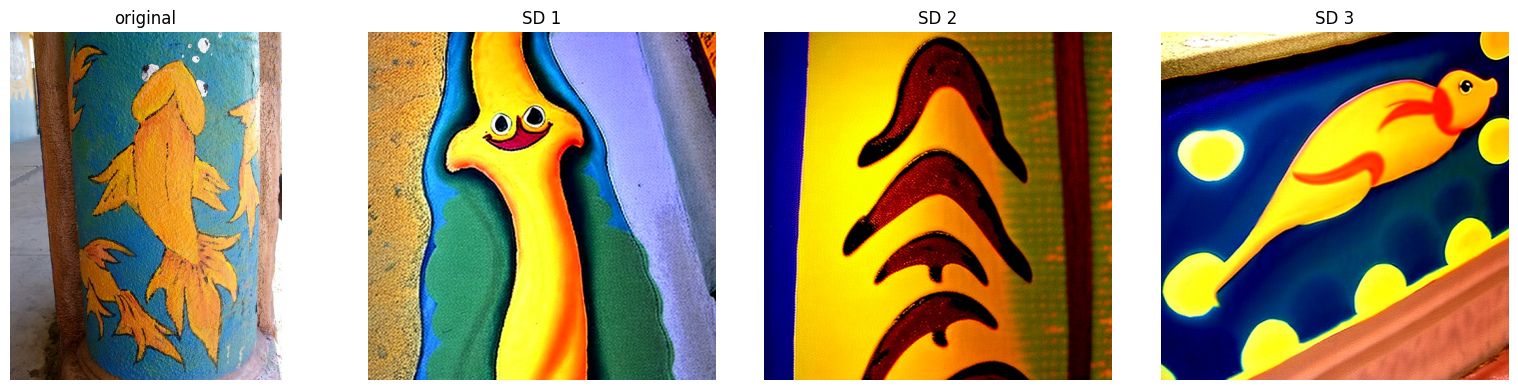

In [ ]:
from diffusers import StableDiffusionImageVariationPipeline
from torchvision import transforms
import torch
import matplotlib.pyplot as plt
import torchvision.datasets as dset

# 모델 로드 (이미 캐시됨)
pipe = StableDiffusionImageVariationPipeline.from_pretrained(
    "lambdalabs/sd-image-variations-diffusers",
    revision="v2.0",
    torch_dtype=torch.float16  # 속도 향상
)
pipe = pipe.to("cuda")
pipe.safety_checker = lambda images, clip_input: (images, [False] * len(images))  # 오류 수정

# 전처리
tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(
        (224, 224),
        interpolation=transforms.InterpolationMode.BICUBIC,
        antialias=False,
    ),
    transforms.Normalize(
        [0.48145466, 0.4578275, 0.40821073],
        [0.26862954, 0.26130258, 0.27577711]
    ),
])

# 이미지 1장 로드
dataset = dset.ImageFolder(root="/content/imagenet-r")
pil_image, label = dataset[0]

# SD로 3장 생성 후 시각화
tensor = tform(pil_image).unsqueeze(0).half().to("cuda")  # fp16

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(pil_image)
axes[0].set_title("original")
axes[0].axis("off")

with torch.no_grad():
    for i in range(3):
        output = pipe(tensor, guidance_scale=10).images[0]
        axes[i+1].imshow(output)
        axes[i+1].set_title(f"SD {i+1}")
        axes[i+1].axis("off")

plt.tight_layout()
plt.show()

### Stable Diffusion Image-to-Image
- 원본 이미지 → 노이즈 추가 → 복원
- strength로 변형 정도 조절 (0에 가까울수록 원본 유지, 1에 가까울수록 많이 변형)
- 현재 strength=0.3으로 설정해 구조 대부분 유지

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

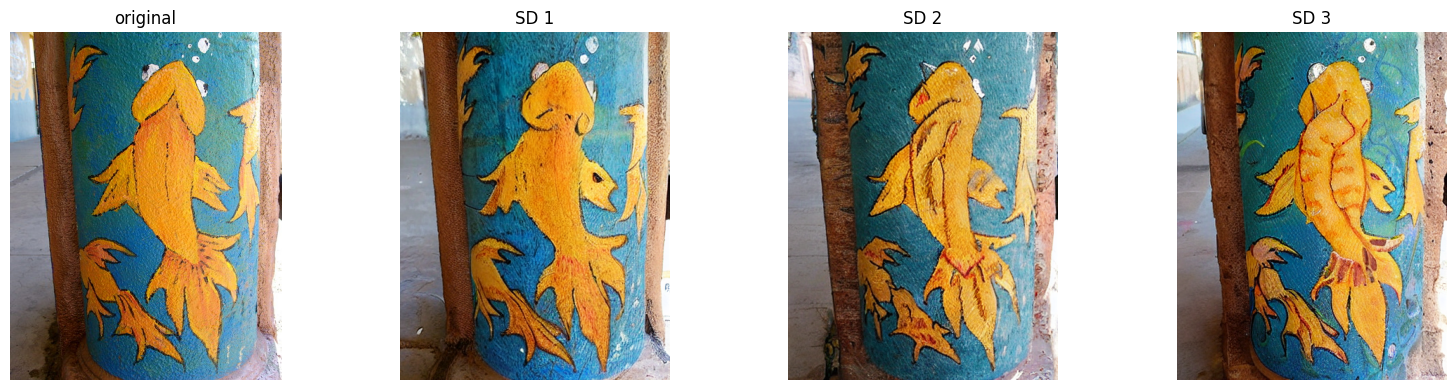

In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline
import torch
import matplotlib.pyplot as plt
import torchvision.datasets as dset

# 모델 로드
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# 이미지 1장 로드
dataset = dset.ImageFolder(root="/content/imagenet-r")
pil_image, label = dataset[0]

# SD img2img로 3장 생성 후 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(pil_image)
axes[0].set_title("original")
axes[0].axis("off")

with torch.no_grad():
    for i in range(3):
        output = pipe(
            prompt="a photo of a fish",
            image=pil_image,
            strength=0.3,
            guidance_scale=1.0
        ).images[0]
        axes[i+1].imshow(output)
        axes[i+1].set_title(f"SD {i+1}")
        axes[i+1].axis("off")

plt.tight_layout()
plt.show()

### ControlNet
- 원본 이미지 → 엣지/윤곽선 추출 → 그 구조 유지하면서 변형
- 구조(형태)는 거의 그대로, 스타일만 바뀜
- 텍스트 프롬프트 필수

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

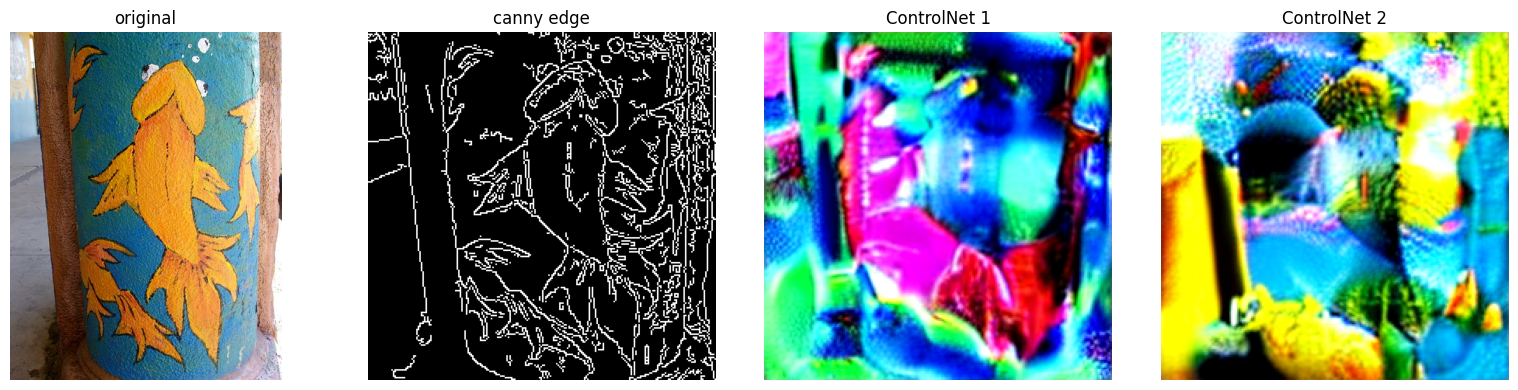

In [ ]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.datasets as dset
from PIL import Image

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")
pipe.safety_checker = lambda images, clip_input: (images, [False] * len(images))

dataset = dset.ImageFolder(root="/content/imagenet-r")
pil_image, label = dataset[0]

image_np = np.array(pil_image.resize((224, 224)))
canny = cv2.Canny(image_np, 100, 200)
canny = Image.fromarray(np.stack([canny]*3, axis=2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(pil_image)
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(canny)
axes[1].set_title("canny edge")
axes[1].axis("off")

with torch.no_grad():
    for i in range(2):
        output = pipe(
            prompt="a high quality photo",
            image=canny,
            num_inference_steps=20,
            guidance_scale=7.5
        ).images[0]
        axes[i+2].imshow(output)
        axes[i+2].set_title(f"ControlNet {i+1}")
        axes[i+2].axis("off")

plt.tight_layout()
plt.show()